Installing the required libraries

In [4]:
!pip install -r ../requirements.txt

  Using cached transformers-4.33.0-py3-none-any.whl.metadata (119 kB)
  Using cached fastapi-0.103.1-py3-none-any.whl.metadata (24 kB)
  Using cached uvicorn-0.23.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached pydantic-2.3.0-py3-none-any.whl.metadata (148 kB)
  Using cached pandas-2.1.0.tar.gz (4.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\gyanr\AppData\Local\Temp\pip-install-37u40kz3\pandas_404c1d77493e452580314948537ba3c9 C:\Users\gyanr\AppData\Local\Temp\pip-install-37u40kz3\pandas_404c1d77493e452580314948537ba3c9\.mesonpy-d0a0ct8f\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\gyanr\AppData\Local\Temp\pip-install-37u40kz3\pandas_404c1d77493e452580314948537ba3c9\.mesonpy-d0a0ct8f\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.0.1
      Source dir: C:\Users\gyanr\AppData\Local\Temp\pip-install-37u40kz3\pandas_404c1d77493e452580314948537ba3c9
      Build dir: C:\Users\gyanr\AppData\Local\Temp\pip-install-37u40kz3\pandas_404c1d77493e452580314948537ba3c9\.mesonpy-d0a0ct8f\build
      Build type: native build
      Project name: pandas
      Project version: 2.1.0
    

Loading and cleaning Data

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('../data/train.csv')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB


In [6]:
data.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [7]:
data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [30]:
print("The count of each label:")
print(data.sum(numeric_only=True))

print("The proportion of 'toxic' label in percentage:")
print((data['toxic'].sum(numeric_only=True)/data.shape[0])*100)


The count of each label:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64
The proportion of 'toxic' label in percentage:
9.584448302009765


Ploting the Distribution of the comments:

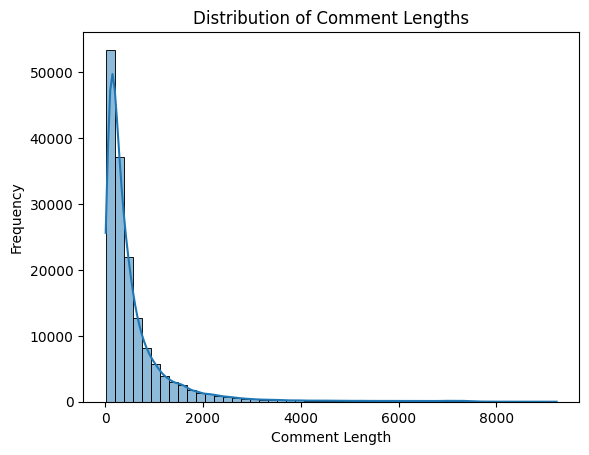

In [17]:
sequence_length = data['comment_text'].apply(lambda x: len(str(x.split())))
sns.histplot(sequence_length, bins=50, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [21]:
import numpy as np
print("Finding the 95th and 90th percentiles of comment lengths:")
p95 = np.percentile(sequence_length,95)
p90 = np.percentile(sequence_length,90)

print(f"95th percentile: {p95}")
print(f"90th percentile: {p90}")

Finding the 95th and 90th percentiles of comment lengths:
95th percentile: 2039.0
90th percentile: 1340.0
